In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_dense_adj, train_test_split_edges
import warnings
warnings.filterwarnings('ignore')

print("PyTorch verzija:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch verzija: 2.11.0+cu130
Device: cpu


In [14]:
dataset = Planetoid(root='./data', name='Cora')
data = dataset[0]

print("=== CORA DATASET ===")
print(f"Broj čvorova:     {data.num_nodes}")
print(f"Broj grana:       {data.num_edges}")
print(f"Feature dimenzija: {data.num_node_features}")
print(f"Broj klasa:       {dataset.num_classes}")
print(f"\nOblik X matrice:  {data.x.shape}")
print(f"Oblik edge_index: {data.edge_index.shape}")

=== CORA DATASET ===
Broj čvorova:     2708
Broj grana:       10556
Feature dimenzija: 1433
Broj klasa:       7

Oblik X matrice:  torch.Size([2708, 1433])
Oblik edge_index: torch.Size([2, 10556])


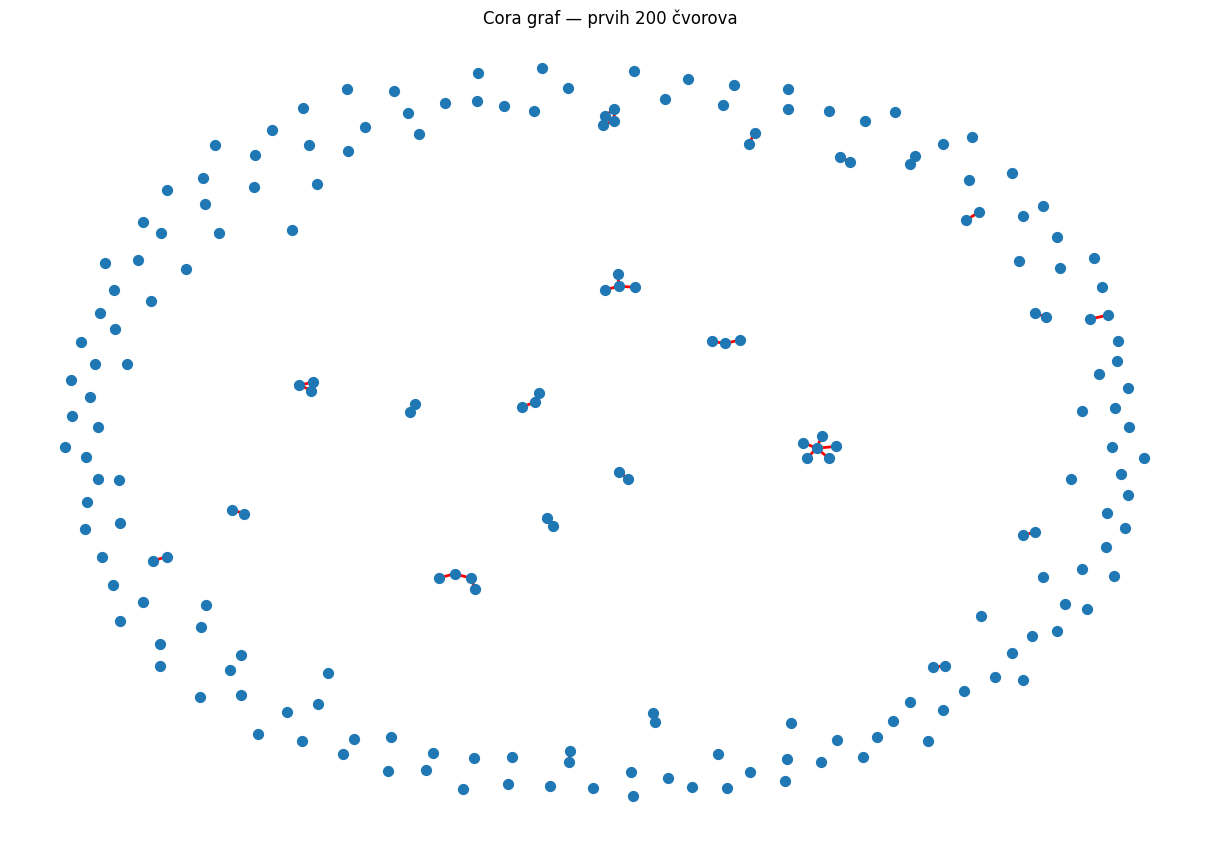

Vizualizacija sačuvana u results/


In [15]:
import networkx as nx #python lib za rad sa grafovima
from torch_geometric.utils import to_networkx #fja koja pytorch geometric graf pretvara u networkx graf

subdata = data.subgraph(torch.arange(200))
G = to_networkx(subdata, to_undirected=True)

plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, seed = 42)
nx.draw(G, pos, node_size = 50, edge_color = 'red', alpha = 1, width = 2)
plt.title("Cora graf — prvih 200 čvorova")
plt.tight_layout()
plt.savefig('../results/cora_visualization.png', dpi=150)
plt.show()
print("Vizualizacija sačuvana u results/")

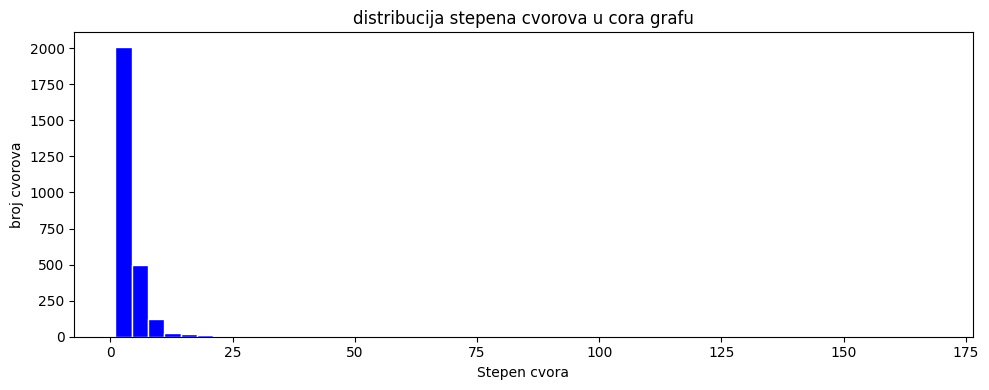

prosecan stepen: 3.90
maksimalan stepen: 168
minimalan stepen: 1


In [17]:
from torch_geometric.utils import degree

deg = degree(data.edge_index[0], num_nodes = data.num_nodes).numpy() #konvertuje pytorch tenzor u numpy array jer matplotlib radi sa numpy

plt.figure(figsize=(10,4))
plt.hist(deg, bins = 50, color = 'blue', edgecolor= 'white')
plt.xlabel("Stepen cvora")
plt.ylabel("broj cvorova")
plt.title("distribucija stepena cvorova u cora grafu")
plt.tight_layout()
plt.savefig('../results/degree_distribution.png', dpi = 150)
plt.show()

print(f"prosecan stepen: {deg.mean():.2f}")
print(f"maksimalan stepen: {deg.max():.0f}")
print(f"minimalan stepen: {deg.min():.0f}")